In [1]:
import pandas as pd
import utils as uti
import matplotlib.pyplot as plt
import pickle

In [2]:
df_train = pd.read_pickle("../data/train_df.pkl")
df_test = pd.read_pickle("../data/test_df.pkl")
walds = pd.read_pickle("../data/walds.pkl")

In [3]:
with open("../data/models.pkl", "rb") as file:
    models = pickle.load(file)

In [4]:
walds.head()

,var,wald,corr,corr ind
0,V14,1951.546659,-0.099085,False
1,V4,1703.435651,-0.106422,False
2,V10,1617.13706,-0.102396,False
3,V3,1541.035483,-0.420856,True
4,V2,1478.19184,-0.530143,True


In [5]:
models

{'logi': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x7eb274579d30>,
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9077744952992656, device=None,
               early_stopping_rounds=None, enable_categorical=True,
               eval_metric='auc', feature_types=None, feature_weights=None,
               gamma=0.025654634309138613, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.021710238946424498, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=4.070881746169755, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...),
 'rf': RandomForestClassifier(class_weight='balan

# predict logistic

In [6]:
import statsmodels.api as sm

In [7]:
models['logi'].params.index.tolist()[1:]

['V14', 'V4', 'V13', 'V12', 'V16', 'V8']

In [8]:
tmp = sm.add_constant(
    df_train[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi'] = models['logi'].predict(tmp)

In [9]:
tmp = sm.add_constant(
    df_test[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi'] = models['logi'].predict(tmp)

# predict XGB

In [10]:
df_train['xgb'] = models['xgb'].predict_proba(df_train[models['xgb'].get_booster().feature_names])[:, 1]

In [11]:
df_test['xgb'] = models['xgb'].predict_proba(df_test[models['xgb'].get_booster().feature_names])[:, 1]

# predict Random Forest

In [12]:
df_train['rf'] = models['rf'].predict_proba(df_train[models['rf'].feature_names_in_.tolist()])[:, 1]

In [13]:
df_test['rf'] = models['rf'].predict_proba(df_test[models['rf'].feature_names_in_.tolist()])[:, 1]

# compare performance

In [14]:
df_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,logi,xgb,rf
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,0.0,0.000104,0.000223,0.0
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,0.0,0.000222,0.000258,0.0
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0.0,0.000067,0.000287,0.0
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,0.0,0.000143,0.000230,0.0
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,0.0,0.000104,0.000237,0.0


In [15]:
df_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,logi,xgb,rf
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00,0.0,0.000149,0.000282,0.000000
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,0.042996,-0.027660,-0.910247,0.110802,-0.511938,11.85,0.0,0.000052,0.000260,0.000000
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-1.483996,-0.296011,0.062823,0.552411,0.509764,76.07,0.0,0.014499,0.013024,0.023562
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.99,0.0,0.000186,0.000252,0.000000
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,0.619449,0.818998,-0.330525,0.046884,0.104527,1.50,0.0,0.004542,0.006752,0.066431


In [16]:
def auc_plot(df_1, df_2):

    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, roc_auc_score
    models = {
        "Logistic regression": "logi",
        "XGBoost": "xgb",
        "Random forest": "rf"
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        sharex=True,
        sharey=True
    )

    for ax, df, title in zip(
        axes,
        [df_1, df_2],
        ['Train', 'Test']
    ):
        y_true = df["Class"]

        for model_name, probability_column in models.items():
            probabilities = df[probability_column]

            fpr, tpr, _ = roc_curve(
                y_true,
                probabilities
            )

            auc_score = roc_auc_score(
                y_true,
                probabilities
            )

            ax.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f"{model_name}: AUC = {auc_score:.3f}"
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Random classifier"
        )

        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right")

    fig.suptitle("ROC Curves by Dataset", fontsize=15)
    plt.tight_layout()
    plt.show()

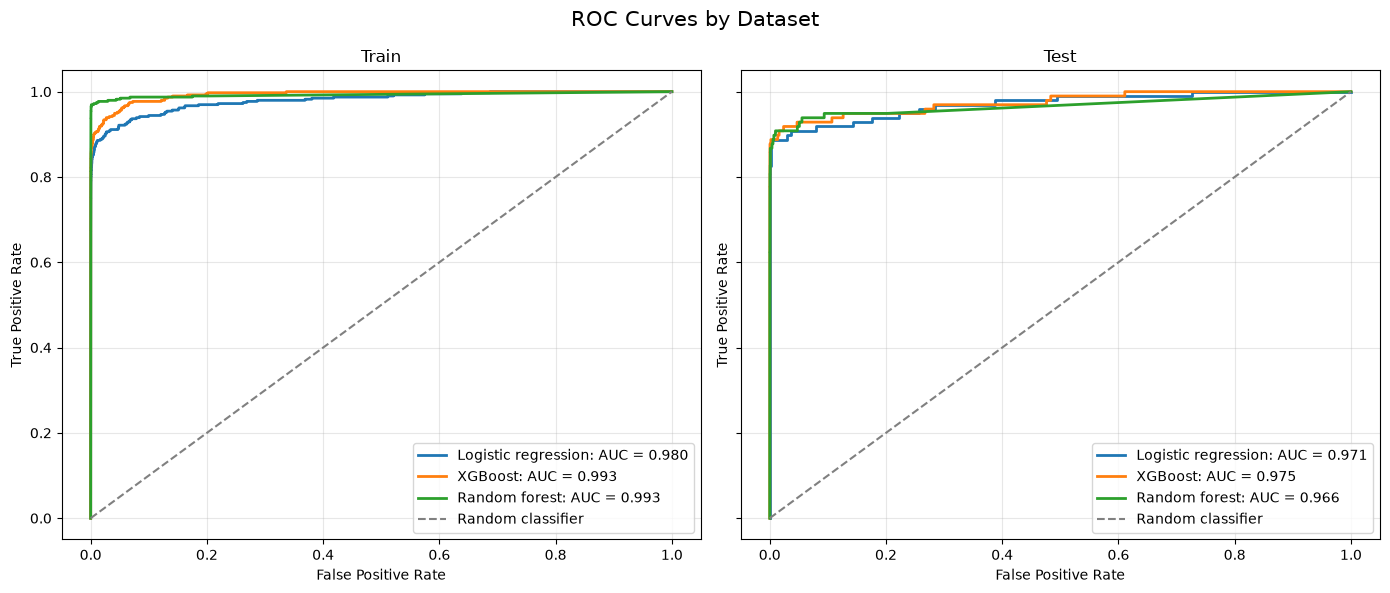

In [17]:
auc_plot(df_train, df_test)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve


def calibration_plot(
    df_1,
    df_2,
    title_1="Train",
    title_2="Test",
    n_bins=10
):
    models = {
        "Logistic regression": "logi",
        "XGBoost": "xgb",
        "Random forest": "rf"
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    for ax, df, title in zip(
        axes,
        [df_1, df_2],
        [title_1, title_2]
    ):
        y_true = df["Class"]

        all_x_values = []
        all_y_values = []

        for model_name, probability_column in models.items():
            predicted_probability = df[probability_column]

            observed_probability, mean_predicted_probability = (
                calibration_curve(
                    y_true,
                    predicted_probability,
                    n_bins=n_bins,
                    strategy="quantile"
                )
            )

            all_x_values.extend(mean_predicted_probability)
            all_y_values.extend(observed_probability)

            ax.plot(
                mean_predicted_probability,
                observed_probability,
                marker="o",
                linewidth=2,
                label=model_name
            )

        # Include both x and y values when determining plot limits
        all_values = np.concatenate([
            np.asarray(all_x_values),
            np.asarray(all_y_values)
        ])

        value_min = all_values.min()
        value_max = all_values.max()

        # Add a small amount of padding
        data_range = value_max - value_min

        if data_range == 0:
            padding = 0.01
        else:
            padding = data_range * 0.05

        plot_min = max(0, value_min - padding)
        plot_max = min(1, value_max + padding)

        ax.plot(
            [plot_min, plot_max],
            [plot_min, plot_max],
            linestyle="--",
            color="gray",
            label="Perfect calibration"
        )

        ax.set_xlim(plot_min, plot_max)
        ax.set_ylim(plot_min, plot_max)

        ax.set_title(title)
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Observed event probability")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")

    fig.suptitle(
        "Predicted vs Observed Event Probabilities",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()


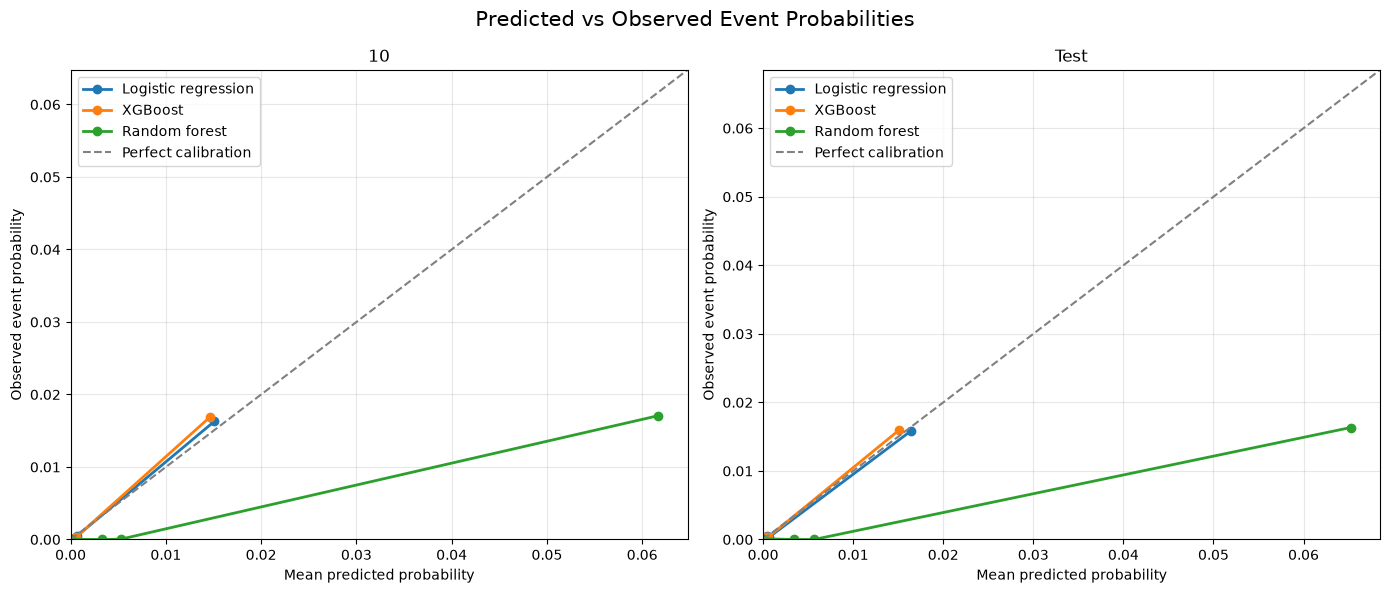

In [19]:
calibration_plot(df_train, df_test, 10)

# save predictions

In [20]:
df_train['sample'] = 'train'
df_test['sample'] = 'test'

In [21]:
results = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

In [23]:
results.to_pickle("../data/results_df.pkl")